In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore') 
df = pd.read_excel('../data/raw/Online Retail.xlsx') 
print(f'Shape: {df.shape}') 
print(f'Columns: {list(df.columns)}') 
print(f'Date range: {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}') 
print(f'\nNull counts:') 
print(df.isnull().sum()) 
print(f'\nCustomerID null: {df["CustomerID"].isnull().mean()*100:.1f}%') 
df.head() 

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

Null counts:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

CustomerID null: 24.9%


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
# Remove rows with no CustomerID 
df = df.dropna(subset=['CustomerID']) 
df['CustomerID'] = df['CustomerID'].astype(int).astype(str) 
  
# Remove returns (negative quantity) 
df = df[df['Quantity'] > 0] 
  
# Remove cancellations (Invoice starting with C) 
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')] 
  
# Remove zero/negative prices 
df = df[df['UnitPrice'] > 0] 
  
# Compute revenue 
df['Revenue'] = df['Quantity'] * df['UnitPrice'] 
  
print(f'After cleaning: {len(df):,} rows, {df["CustomerID"].nunique():,} customers') 
print(f'Date range: {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}') 

After cleaning: 397,884 rows, 4,338 customers
Date range: 2010-12-01 to 2011-12-09


In [12]:
# snapshot_date = day after last transaction 
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1) 
print(f'Snapshot date: {snapshot_date.date()}') 
  
# Aggregate to customer level 
rfm = df.groupby('CustomerID').agg( 
    last_purchase  = ('InvoiceDate', 'max'), 
    first_purchase = ('InvoiceDate', 'min'), 
    frequency      = ('InvoiceNo',     'nunique'), 
    monetary       = ('Revenue',     'sum'), 
).reset_index() 
  
rfm['recency_days']  = (snapshot_date - rfm['last_purchase']).dt.days 
rfm['T_days']        = (snapshot_date - rfm['first_purchase']).dt.days 
rfm['avg_order_val'] = rfm['monetary'] / rfm['frequency'] 
print(f'\nRFM summary:') 
print(rfm[['frequency','recency_days','T_days','monetary','avg_order_val']].describe().round(2)) 

Snapshot date: 2011-12-10

RFM summary:
       frequency  recency_days   T_days   monetary  avg_order_val
count    4338.00       4338.00  4338.00    4338.00        4338.00
mean        4.27         92.54   223.31    2054.27         419.17
std         7.70        100.01   117.89    8989.23        1796.54
min         1.00          1.00     1.00       3.75           3.45
25%         1.00         18.00   113.00     307.41         178.62
50%         2.00         51.00   249.00     674.48         293.90
75%         5.00        142.00   327.00    1661.74         430.11
max       209.00        374.00   374.00  280206.02       84236.25


Churn rate (90-day threshold): 33.6%
Churned customers: 1,458
Active customers:  2,880


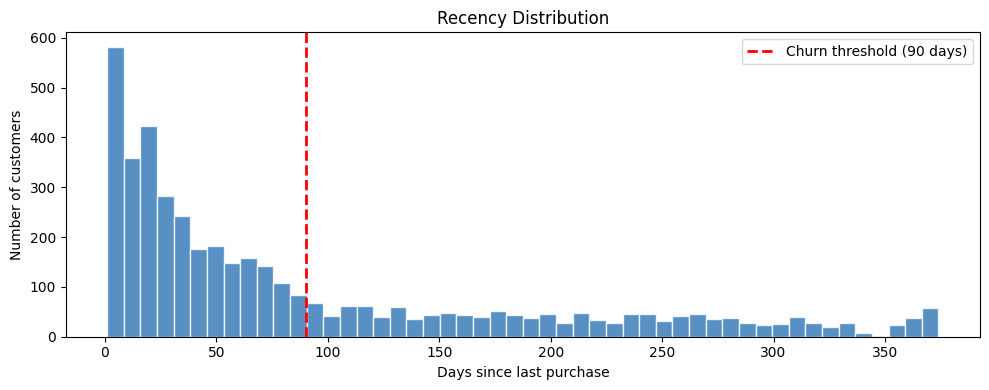

In [13]:
# Churn = no purchase in last 90 days 
churn_threshold = 90 
rfm['churned'] = (rfm['recency_days'] >= churn_threshold).astype(int) 
  
print(f'Churn rate ({churn_threshold}-day threshold): {rfm["churned"].mean()*100:.1f}%') 
print(f'Churned customers: {rfm["churned"].sum():,}') 
print(f'Active customers:  {(1-rfm["churned"]).sum():,}') 
  
# Plot recency distribution with churn threshold 
fig, ax = plt.subplots(figsize=(10, 4)) 
ax.hist(rfm['recency_days'], bins=50, color='#2E75B6', edgecolor='white', 
alpha=0.8) 
ax.axvline(churn_threshold, color='red', linestyle='--', linewidth=2, 
           label=f'Churn threshold ({churn_threshold} days)') 
ax.set_xlabel('Days since last purchase') 
ax.set_ylabel('Number of customers') 
ax.set_title('Recency Distribution') 
ax.legend() 
plt.tight_layout() 
plt.show() 

In [14]:
# frequency = number of repeat purchases (first purchase excluded) 
# recency = time between first and last purchase (in weeks) 
# T = customer age (time since first purchase, in weeks) 
  
rfm['frequency_bgn'] = rfm['frequency'] - 1          # repeat purchases only 
rfm['recency_weeks'] = rfm['T_days'] - rfm['recency_days'] 
rfm['recency_weeks'] = rfm['recency_weeks'] / 7 
rfm['T_weeks']       = rfm['T_days'] / 7 
  
# Filter: BG/NBD needs at least 1 repeat purchase for meaningful fit 
# Keep all customers for churn model, flag one-time buyers separately 
rfm['one_time_buyer'] = (rfm['frequency'] == 1).astype(int) 
print(f'One-time buyers: {rfm["one_time_buyer"].mean()*100:.1f}%') 
print(f'\nBG/NBD ready columns:') 
print(rfm[['frequency_bgn','recency_weeks','T_weeks']].describe().round(2)) 

One-time buyers: 34.4%

BG/NBD ready columns:
       frequency_bgn  recency_weeks  T_weeks
count        4338.00        4338.00  4338.00
mean            3.27          18.68    31.90
std             7.70          18.89    16.84
min             0.00           0.00     0.14
25%             0.00           0.00    16.14
50%             1.00          13.29    35.57
75%             4.00          36.00    46.71
max           208.00          53.29    53.43


In [17]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

# ── Step 1: Fit BG/NBD ────────────────────────────────────────
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm['frequency_bgn'], rfm['recency_weeks'], rfm['T_weeks'])

# Predict expected purchases in next 12 weeks
rfm['predicted_purchases_12w'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    12, rfm['frequency_bgn'], rfm['recency_weeks'], rfm['T_weeks']
)

# BG/NBD alive probability — this becomes a churn classifier feature
rfm['p_alive'] = bgf.conditional_probability_alive(
    rfm['frequency_bgn'], rfm['recency_weeks'], rfm['T_weeks']
)

# ── Step 2: Fit Gamma-Gamma ───────────────────────────────────
# Gamma-Gamma only uses customers with at least 1 repeat purchase
gg_df = rfm[rfm['frequency_bgn'] > 0].copy()

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(gg_df['frequency_bgn'], gg_df['avg_order_val'])

# Expected average transaction value
rfm['expected_avg_order_val'] = ggf.conditional_expected_average_profit(
    rfm['frequency_bgn'], rfm['avg_order_val']
)

# ── Step 3: Compute CLV ───────────────────────────────────────
# CLV = expected purchases × expected average order value
rfm['clv_12w'] = rfm['predicted_purchases_12w'] * rfm['expected_avg_order_val']

print(rfm[['predicted_purchases_12w', 'p_alive', 'expected_avg_order_val', 'clv_12w']].describe().round(2))

       predicted_purchases_12w  p_alive  expected_avg_order_val   clv_12w
count                  4120.00  4338.00                 4338.00   4120.00
mean                      1.14     0.98                  298.44    516.88
std                       1.64     0.07                 1625.59   2092.16
min                       0.00     0.00                  -21.42    -15.44
25%                       0.37     0.98                  -21.42     -3.64
50%                       0.70     1.00                  208.67    191.77
75%                       1.37     1.00                  390.30    512.87
max                      41.42     1.00               101889.75  58112.20


In [18]:
# Cap avg_order_val at 99th percentile before fitting Gamma-Gamma
p99 = rfm['avg_order_val'].quantile(0.99)
rfm['avg_order_val_capped'] = rfm['avg_order_val'].clip(upper=p99)
print(f"99th percentile cap: £{p99:.2f}")

# Use the capped version for Gamma-Gamma
gg_df = rfm[rfm['frequency_bgn'] > 0].copy()
ggf.fit(gg_df['frequency_bgn'], gg_df['avg_order_val_capped'])

99th percentile cap: £2031.16


<lifetimes.GammaGammaFitter: fitted with 2845 subjects, p: 3.83, q: 0.34, v: 3.72>